# Compare ABL profiles

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D
import SANDwake3D_base as sdb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# y-z mesh
dz   = 10
zmin = 2 #2.00
zmax = zmin + 400
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

dy   = 10
ymax = 400
Ny   = int((2*ymax)/dy+1)
yvec = np.linspace(-ymax,ymax,Ny)
#Ny=51
#ymax = 125
#yvec = np.linspace(-ymax,ymax,Ny)

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 10.0
dz = 10.0
(81, 41)


In [5]:
turbhh = 150.0
rotorD = 240
turbR  = rotorD*0.5

# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : 1.5E-5,
    'Cmu' : 5.48**(-2),
    'C1eps' : 1.76,
    'C2eps' : 1.92, #3.50, #1.92,
    'C3eps' : -1, #0.033,
    'sigmak' : 1.0, 
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':  0.5,
    
    'ustar' : 0.175, 
    'qw': -0.40, #-0.050,
    'L' : 500,
    'kappa' : 0.42,
    'z0' : 0.0001, #0.0005,

    'zlo':zmin,
    'Tw':300.0,
    'beta':1.0/300.0,
    'Tref':300.0,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    
    'turbforcing':{'turbx':80.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':turbhh,      # Turbine hub-height
                   'turbD':rotorD,   # Turbine diameter
                   'Ct':0.80,
                   'Rdelta':5, #40,
                   'turbfunc':sdb.tanhADM,
                  }
}

# This parameter defines V(z) -- deg per meter
veerpermeter = 0.05 #0.05 #0.02
Tpermeter    = 0.002 #0.002 #0.0025

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
veerProf = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerProf[i] = veerpermeter*(z-turbhh)
    
Uprof, Vprof = SANDwake3D.getUVfromUhVeer(UABL, veerProf)
    
tempT = np.zeros(Nz)
for i, z in enumerate(zvec):
    tempT[i] = params['Tw'] + Tpermeter*z
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, Uprof), np.interp(zbot, zvec, Uprof)
Vtop, Vbot = np.interp(ztop, zvec, Vprof), np.interp(zbot, zvec, Vprof)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  6.550254250072273
alpha =  0.138981216713553
rotor veer =  11.997684492740579


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.zeros((Ny, Nz)) #np.ones((Ny, Nz))*params['Tref']
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = Uprof[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = Vprof[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)
    
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*np.exp(-0.0*z)*1.0 + 0.0 #0.02 #0.15 #0.0075 #0.01 #0.02
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*np.exp(-0.015*z)*0.25 + 0.03 #GOOD
    
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    Tinit[:, iz] = tempT[iz]
    
phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

params['Tref']=Tinit+0.0

(0.0, 402.0)

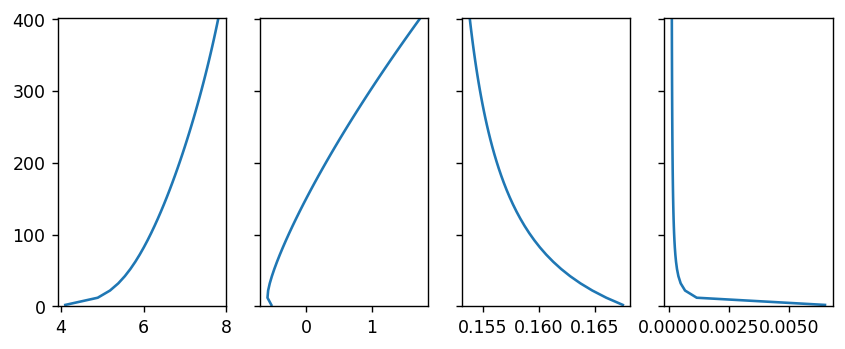

In [8]:
fig, axs = plt.subplots(1,4, sharey=True, dpi=125, figsize=(8,3))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Vinit[Ny//2,:], zvec)
axs[2].plot(Kinit[Ny//2,:], zvec)
axs[3].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [9]:
xvecplot=[0, 80, 560, 2480]
#xvecplot=[0, 200]
dx  = 80

xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec=[0, 200, 400, 600]

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], tempT[-1], veerBC=Vprof, dTdz=Tpermeter, uBC_y=Uprof),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 80.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.12677743291207963, 'Lnext': 457.06785410442956, 'Tstar': 0.0025638214286746973}
avg_dil: 0.00026572676346026634
x = 160.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.13608605193766968, 'Lnext': 565.8429706520877, 'Tstar': 0.002389566666059706}
avg_dil: 0.00012096905044761307
x = 240.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.13194595827627137, 'Lnext': 515.8058117371181, 'Tstar': 0.0024645174600045508}
avg_dil: 0.0001199990487804201
x = 320.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.1302374940261417, 'Lnext': 496.3623494557141, 'Tstar': 0.002497472082647168}
avg_dil: 0.00011829072988860051
x = 400.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.12809058466695256, 'Lnext': 472.81621033027767, 'Tstar': 0.002540572408763903}
avg_dil: 0.00011743236892177979
x = 480.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.12614526803782644, 'Lnext': 452.4821103708727, 'Tstar': 0.0025817088234075932}
avg_dil: 0.0001166884969404033
x = 560.0 dx = 80.0
ZLO_WALLBC: {'ustar': 0.12430016464254283, 'Lnext': 434

(2.0, 402.0)

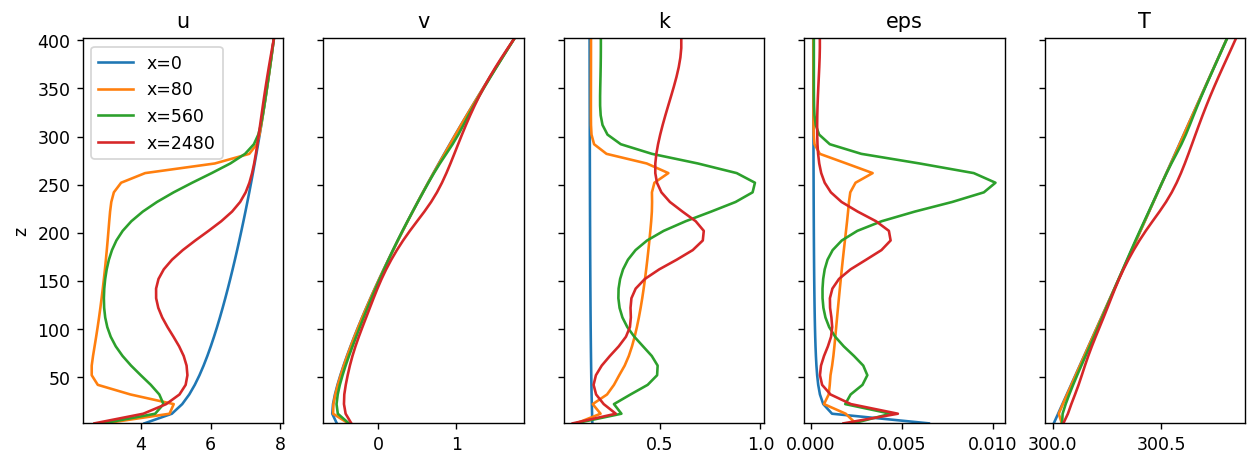

In [10]:
plotvars=['u', 'v', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,4), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        #axs[iv].plot(phi[v][ixRANS,islice,:]/phi[v][0,islice,:], zvec, label='x=%.0f'%x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

## Plot comparison

In [11]:
def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

Text(0.5, 0, 'TI [-]')

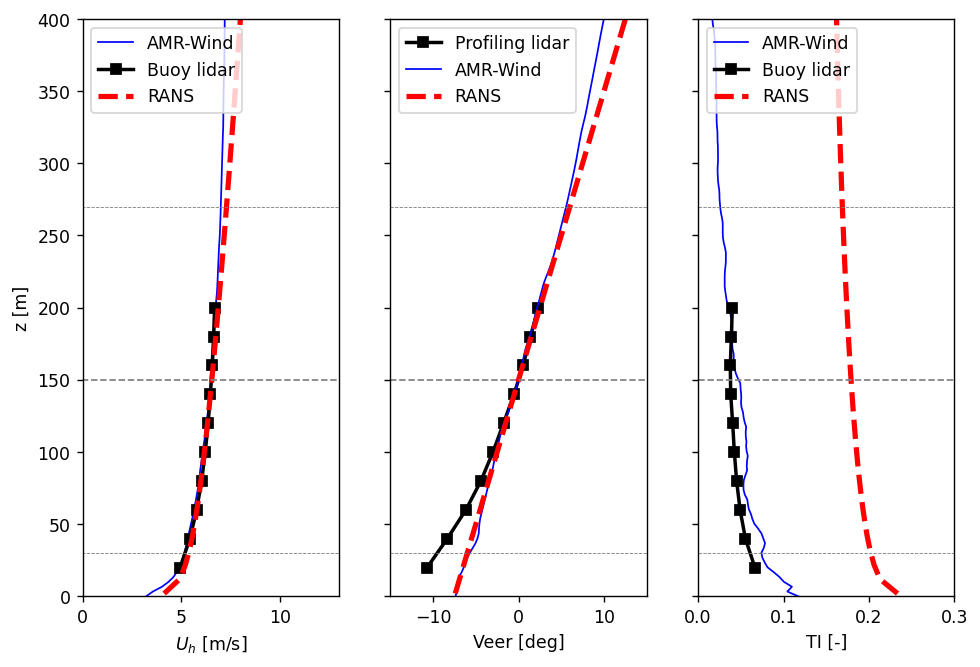

In [12]:
lidardir='./'

# Plot wind speed
WS_z     = np.loadtxt(lidardir+'/LowWS_LowTI_heights.dat')
WS_lidar = np.loadtxt(lidardir+'/LowWS_LowTI_WSmean.dat')
WDC_lidar = np.loadtxt(lidardir+'/LowWS_LowTI_WDCmean.dat')
TI_lidar = np.loadtxt(lidardir+'/LowWS_LowTI_TImean.dat')
AMRdat   = np.loadtxt(lidardir+'/AMRWIND_LowWS_LowTI_metmast.dat')

AMR_WDzhh = np.interp(turbhh, AMRdat[:,0], AMRdat[:,4])

#iRANS=-1
iRANS=0
fig, axs = plt.subplots(1,3, figsize=(9,6), dpi=125, sharey=True)

# --- plot velocity ---
ax=axs[0]
# Plot AMR-Wind data
ax.plot(AMRdat[:,1], AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)
# Plot lidar data
ax.plot(WS_lidar,WS_z, 'k-', marker='s', label='Buoy lidar', lw=2)
# Plot RANS data
Uh = np.sqrt(phi['u'][iRANS,islice,:]**2 + phi['v'][iRANS,islice,:]**2)
ax.plot(Uh, zvec, 'r--', lw=3, label='RANS')

# --- plot veer ---
ax=axs[1]
ax.plot(WDC_lidar, WS_z, 'k-s',  lw=2, label='Profiling lidar')
ax.plot(AMRdat[:,4]-AMR_WDzhh, AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)

WD_RANS = np.arctan2(phi['v'][iRANS,islice,:], phi['u'][iRANS,islice,:])*180/np.pi
ax.plot(WD_RANS, zvec, 'r--', lw=3, label='RANS')
ax.set_xlim([-15, 15])
ax.set_xlabel('Veer [deg]')
              
# --- plot TI ---
ax=axs[2]
# Plot AMR-Wind data
ax.plot(AMRdat[:,7], AMRdat[:,0], 'b-', label='AMR-Wind', lw=1)
# Plot lidar data
ax.plot(TI_lidar,WS_z, 'k-', marker='s', label='Buoy lidar', lw=2)
# Plot RANS
# TKE = 0.5*(uu + vv + ww)  = 1.5*(uu)
# uu = 2/3*TKE
TI_RANS = np.sqrt((4.0/3.0)*phi['k'][iRANS,islice,:]/phi['u'][iRANS,islice,:])
ax.plot(TI_RANS, zvec, 'r--', lw=3, label='RANS')


for ax in axs:
    ax.set_ylim([0,400])
    ax.legend(loc='upper left')
    # Plot the turbine dimensions
    plotrotorlinesax(ax, turbhh, rotorD, -15, 20, linestyles='dashed', color='gray',)
    
ax=axs[0]
ax.set_xlim([0, 13])
ax.set_xlabel('$U_h$ [m/s]')
ax.set_ylabel('z [m]')

ax=axs[2]
ax.set_xlim([0, 0.3])
ax.set_xlabel('TI [-]')


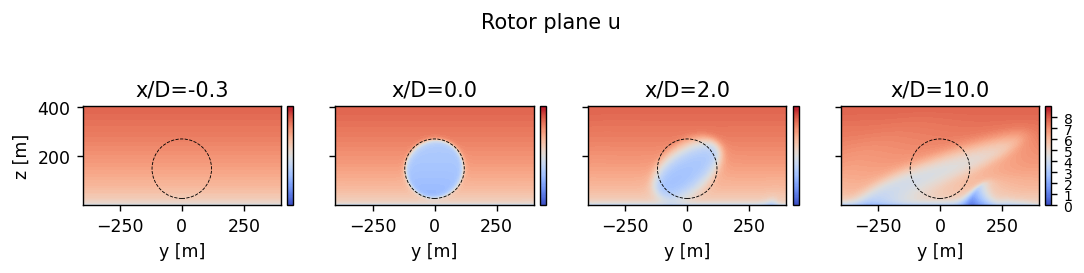

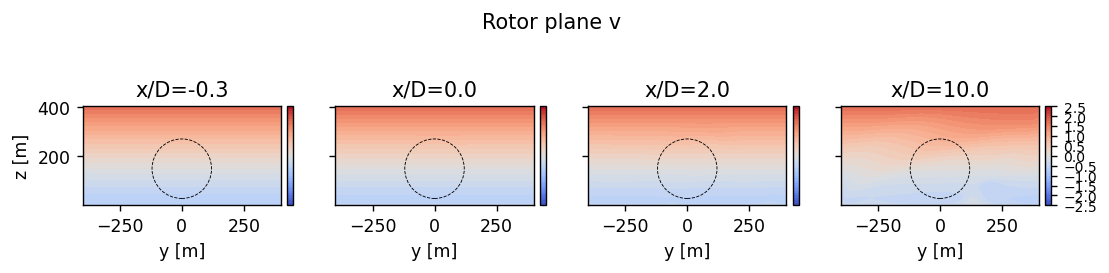

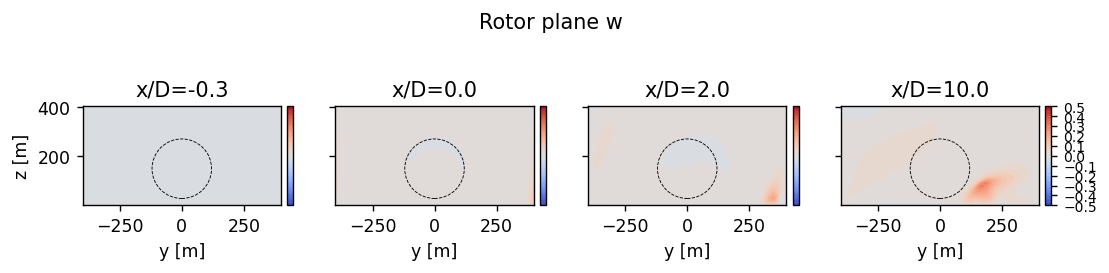

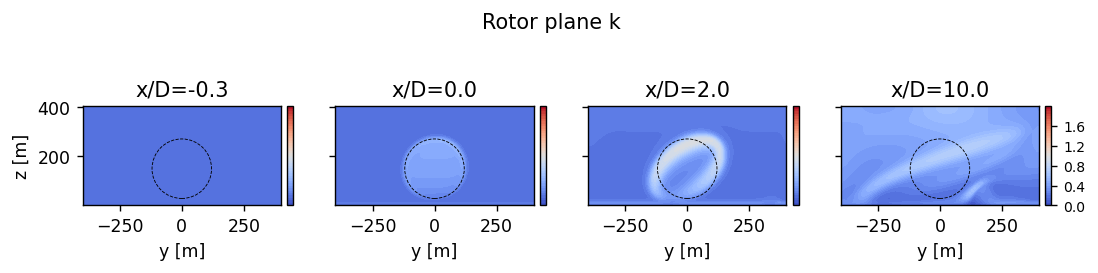

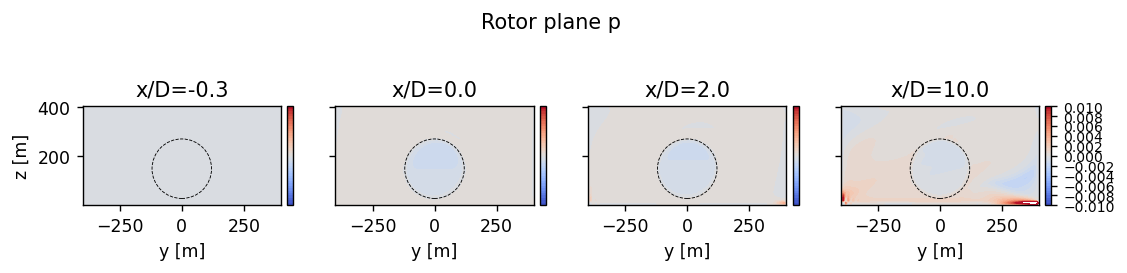

In [13]:
savefigs = False
cbarticks=np.arange(0,11,1)
plotvars=['u','v', 'w', 'k', 'p']
maxV=2.5
maxL=0.5
maxP=0.01
vlevels={'u':{'levels':np.linspace(0,9,91), 'cbarticks':np.arange(0,9,1)},
         'v':{'levels':np.linspace(-maxV,maxV,41), 'cbarticks':np.arange(-maxV, maxV+1E-5,maxV/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'k':{'levels':np.linspace(0,2,41), 'cbarticks':np.arange(0, 2,2.0/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

for plotv in plotvars:
    fig, axs = plt.subplots(1, len(xvecplot), figsize=(len(xvecplot)*2.5,3.25), dpi=125, sharey=True)
    for ix, x in enumerate(xvecplot):
        ixRANS = find_nearest(xvec, x)
        c=axs[ix].contourf(ym, zm, phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
        axs[ix].set_aspect('equal')
        axs[ix].set_title('x/D=%.1f'%((x-params['turbforcing']['turbx'])/rotorD))
        axs[ix].set_xlabel('y [m]')
        rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
        axs[ix].add_patch(rotorcirc)
    
        divider = make_axes_locatable(axs[ix])
        cax = divider.append_axes("right", size="3%", pad=0.05)
        if ix < len(xvecplot)-1:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
        else:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
            cbar.ax.tick_params(labelsize=8)
        
    axs[0].set_ylabel('z [m]')
    plt.suptitle('Rotor plane '+plotv,y=0.85)

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')